In [1]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
from glob import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tifffile
import numpy as np
from typing import Dict, Any
from tqdm import tqdm  # for progress bars
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from umap import UMAP
import pandas as pd
import re
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import f1_score
import h5py
import importlib

In [2]:
# 1. Build list of (filename, j, k) entries
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
all_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.startswith('recons-DA-') and f.endswith('.h5')]

index_list = []

for filename in all_files:
    with h5py.File(filename, 'r') as f:
        if not {'powder-recon', 'crystal-recon', 'crystal-mask'}.issubset(f.keys()):
            continue  # skip files missing required keys
        shape = f['powder-recon'][:,25:-25,50:-50].shape  # (channels, width, depth)
        channels, width, depth = shape
        print(f"Processing {filename} with shape {shape}")

        for j in range(width):  # j iterates over width
            for k in range(depth):  # k iterates over depth
                index_list.append((filename, j, k))

print(f"Total samples: {len(index_list)}")

# 2. Train/test split
train_indices, val_indices = train_test_split(index_list, test_size=0.2, random_state=42)

# 3. Custom Dataset class
class ThresholdedH5Dataset(Dataset):
    def __init__(self, index_list, threshold=1.5, cache_size=1,scale_factor=100.0, use_derivative=False):
        """
        index_list: List of (filename, j, k) tuples
        threshold: Threshold for crystal-mask
        cache_size: How many files to keep in RAM (1 = keep current file only)
        """
        self.index_list = index_list
        self.threshold = threshold
        self.cache_size = cache_size
        self.cache = {}  # filename -> loaded data
        self.scale_factor = scale_factor
        self.use_derivative = use_derivative  # 🔥 new option!

    def __len__(self):
        return len(self.index_list)

    def _load_file(self, filename):
        """Load an entire h5 file into cache."""
        with h5py.File(filename, 'r') as f:
            data = {
                'powder-recon': f['powder-recon'][:][:,25:-25,50:-50],  # copy into memory
                'crystal-recon': f['crystal-recon'][:][:,25:-25,50:-50],
                'crystal-mask': f['crystal-mask'][:][:,25:-25,50:-50]
            }
        return data

    def __getitem__(self, idx):
        filename, j, k = self.index_list[idx]

        # Load file into cache if needed
        if filename not in self.cache:
            if len(self.cache) >= self.cache_size:
                self.cache.clear()  # simple cache clearing for now
            self.cache[filename] = self._load_file(filename)

        data = self.cache[filename]
        powder = data['powder-recon'][:, j, k]
        crystal = data['crystal-recon'][:, j, k]
        mask_value = data['crystal-mask'][:,j, k]

        combined = powder + crystal * (mask_value > self.threshold)
        combined = combined * self.scale_factor
        #combined = combined / np.max(combined)     # Step 2: normalize max to 1
        combined = np.clip(combined, 0.001, None)  # Step 1: clip
        combined = np.log(combined+1)                # Step 3: log transform
        return combined.astype(np.float32)

# 4. DataLoaders
train_dataset = ThresholdedH5Dataset(train_indices, threshold=0.5)
val_dataset = ThresholdedH5Dataset(val_indices, threshold=0.5)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)


Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons-DA-0339.h5 with shape (667, 50, 262)
Total samples: 13100


In [3]:
import neural_networks.convVAE_no_aug
importlib.reload(neural_networks.convVAE_no_aug)
from neural_networks.convVAE_no_aug import ConvVAE
from neural_networks.convVAE_no_aug import HybridVAE
from neural_networks.convVAE_no_aug import PositionalEncodingVAE



In [4]:
modelCNN = ConvVAE(input_channels=667, latent_dim=64, channels=[8, 16, 32]).to('cuda')
modelHybrid = ConvVAE(input_channels=667, latent_dim=64).to('cuda')
modelPositional = PositionalEncodingVAE(input_channels=667, latent_dim=64, pos_encoding_dim=16).to('cuda')


In [7]:
def vae_loss(recon_x, x, mu, logvar, kl_weight=1.0):
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')

    # KL divergence
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    return recon_loss + kl_weight * kl_div, recon_loss.item(), kl_div.item()


def train_vae(
    model,
    train_loader,
    val_loader,
    num_epochs=50,
    lr=1e-3,
    device='cuda',
    kl_anneal_epochs=50  # KL warm-up length
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    kl_weights = []

    count = 0
    for epoch in range(1, num_epochs + 1):
        count = count+1
        model.train()
        running_loss = 0.0

        kl_weight = min(1.0, epoch / kl_anneal_epochs*0.0005)  # linear KL warm-up
        kl_weights.append(kl_weight)

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
            batch = batch.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = model(batch)
            loss, recon_l, kl_l = vae_loss(recon, batch, mu, logvar, kl_weight)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon, mu, logvar = model(batch)
                loss, _, _ = vae_loss(recon, batch, mu, logvar, kl_weight=kl_weight)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch:3d} | Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f} | KL weight: {kl_weight:.2f}")
        if not count%25:
            model.eval()
            with torch.no_grad():
                sample_batch = next(iter(val_loader))  # Take 1 batch from validation loader
                sample_batch = sample_batch.to(device)
                recon_batch, _, _ = model(sample_batch)

                # Take the first sample in batch
                N = np.random.randint(0, 128)
                original = sample_batch[N].cpu().numpy()
                reconstructed = recon_batch[N].cpu().numpy()

                # Plot input and reconstruction
                plt.figure(figsize=(6, 3))
                plt.plot(original, label='Original', linewidth=2)
                plt.plot(reconstructed, label='Reconstruction', linestyle='--')
                plt.title(f'Reconstruction after Epoch {epoch}')
                plt.xlabel('Spectral Dimension')
                plt.ylabel('Value')
                plt.legend()
                plt.grid(True)
                plt.tight_layout()
                plt.show()


    # Plot
    plt.figure(figsize=(6, 3))
    plt.plot(train_losses, label='Train loss')
    plt.plot(val_losses, label='Val loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("VAE Training with KL Warm-up")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return train_losses, val_losses, kl_weights

Epoch   1 | Train loss: 0.0044 | Val loss: 0.0040 | KL weight: 0.00


Epoch   2 | Train loss: 0.0043 | Val loss: 0.0041 | KL weight: 0.00


Epoch   3 | Train loss: 0.0045 | Val loss: 0.0044 | KL weight: 0.00


Epoch   4 | Train loss: 0.0047 | Val loss: 0.0046 | KL weight: 0.00


Epoch   5 | Train loss: 0.0049 | Val loss: 0.0048 | KL weight: 0.00


...

Epoch  21 | Train loss: 0.0071 | Val loss: 0.0071 | KL weight: 0.00


Epoch  22 | Train loss: 0.0072 | Val loss: 0.0071 | KL weight: 0.00


Epoch  23 | Train loss: 0.0073 | Val loss: 0.0072 | KL weight: 0.00


Epoch  24 | Train loss: 0.0074 | Val loss: 0.0073 | KL weight: 0.00


Epoch  25 | Train loss: 0.0074 | Val loss: 0.0075 | KL weight: 0.00


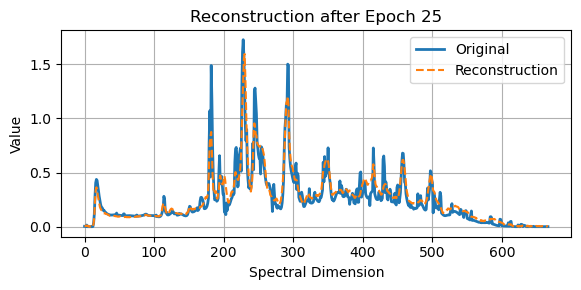

Epoch  26 | Train loss: 0.0075 | Val loss: 0.0074 | KL weight: 0.00


Epoch  27 | Train loss: 0.0075 | Val loss: 0.0075 | KL weight: 0.00


Epoch  28 | Train loss: 0.0076 | Val loss: 0.0075 | KL weight: 0.00


Epoch  29 | Train loss: 0.0077 | Val loss: 0.0076 | KL weight: 0.00


Epoch  30 | Train loss: 0.0078 | Val loss: 0.0077 | KL weight: 0.00


...

Epoch  46 | Train loss: 0.0085 | Val loss: 0.0084 | KL weight: 0.00


Epoch  47 | Train loss: 0.0085 | Val loss: 0.0085 | KL weight: 0.00


Epoch  48 | Train loss: 0.0086 | Val loss: 0.0085 | KL weight: 0.00


Epoch  49 | Train loss: 0.0086 | Val loss: 0.0085 | KL weight: 0.00


Epoch  50 | Train loss: 0.0086 | Val loss: 0.0085 | KL weight: 0.00


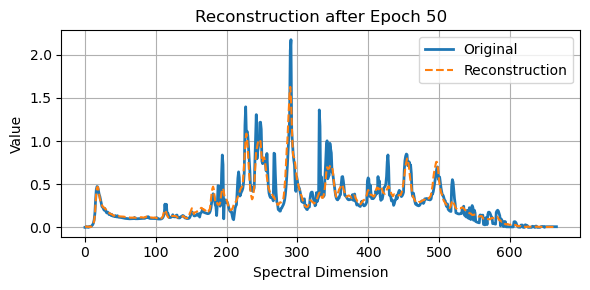

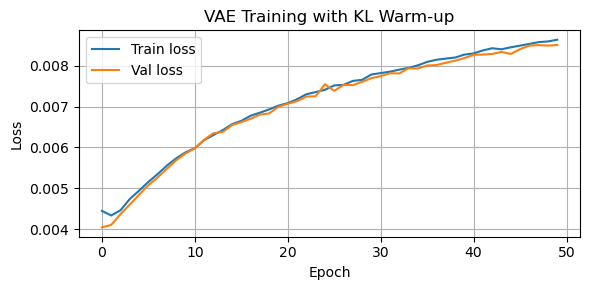

In [8]:
train_losses, val_losses, kl_weights = train_vae(modelCNN, train_loader, val_loader, num_epochs=50)

Epoch   1 | Train loss: 0.0213 | Val loss: 0.0091 | KL weight: 0.00


Epoch   2 | Train loss: 0.0095 | Val loss: 0.0080 | KL weight: 0.00


Epoch   3 | Train loss: 0.0084 | Val loss: 0.0079 | KL weight: 0.00


Epoch   4 | Train loss: 0.0084 | Val loss: 0.0078 | KL weight: 0.00


Epoch   5 | Train loss: 0.0084 | Val loss: 0.0081 | KL weight: 0.00


...

Epoch  21 | Train loss: 0.0076 | Val loss: 0.0075 | KL weight: 0.00


Epoch  22 | Train loss: 0.0077 | Val loss: 0.0076 | KL weight: 0.00


Epoch  23 | Train loss: 0.0077 | Val loss: 0.0076 | KL weight: 0.00


Epoch  24 | Train loss: 0.0077 | Val loss: 0.0077 | KL weight: 0.00


Epoch  25 | Train loss: 0.0078 | Val loss: 0.0077 | KL weight: 0.00


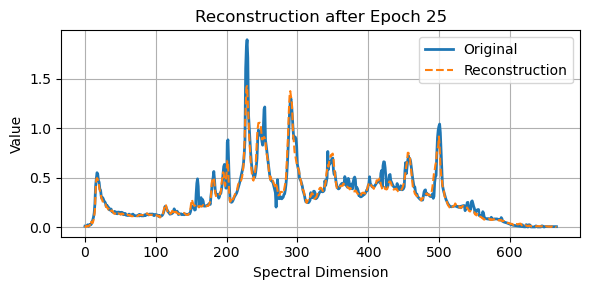

Epoch  26 | Train loss: 0.0078 | Val loss: 0.0077 | KL weight: 0.00


Epoch  27 | Train loss: 0.0079 | Val loss: 0.0078 | KL weight: 0.00


Epoch  28 | Train loss: 0.0079 | Val loss: 0.0078 | KL weight: 0.00


Epoch  29 | Train loss: 0.0079 | Val loss: 0.0078 | KL weight: 0.00


Epoch  30 | Train loss: 0.0080 | Val loss: 0.0078 | KL weight: 0.00


...

Epoch  46 | Train loss: 0.0085 | Val loss: 0.0085 | KL weight: 0.00


Epoch  47 | Train loss: 0.0086 | Val loss: 0.0088 | KL weight: 0.00


Epoch  48 | Train loss: 0.0086 | Val loss: 0.0086 | KL weight: 0.00


Epoch  49 | Train loss: 0.0086 | Val loss: 0.0086 | KL weight: 0.00


Epoch  50 | Train loss: 0.0086 | Val loss: 0.0085 | KL weight: 0.00


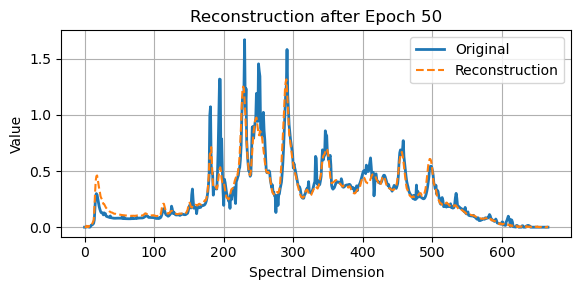

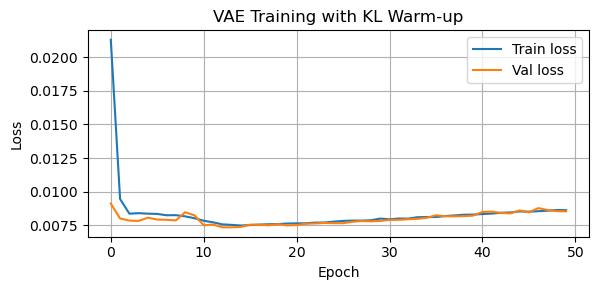

In [9]:

train_losses, val_losses, kl_weights = train_vae(modelHybrid, train_loader, val_loader, num_epochs=50)

Epoch   1 | Train loss: 0.0636 | Val loss: 0.0121 | KL weight: 0.00


Epoch   2 | Train loss: 0.0121 | Val loss: 0.0118 | KL weight: 0.00


Epoch   3 | Train loss: 0.0121 | Val loss: 0.0112 | KL weight: 0.00


Epoch   4 | Train loss: 0.0112 | Val loss: 0.0104 | KL weight: 0.00


Epoch   5 | Train loss: 0.0109 | Val loss: 0.0105 | KL weight: 0.00


...

Epoch  21 | Train loss: 0.0084 | Val loss: 0.0082 | KL weight: 0.00


Epoch  22 | Train loss: 0.0083 | Val loss: 0.0086 | KL weight: 0.00


Epoch  23 | Train loss: 0.0084 | Val loss: 0.0083 | KL weight: 0.00


Epoch  24 | Train loss: 0.0084 | Val loss: 0.0082 | KL weight: 0.00


Epoch  25 | Train loss: 0.0083 | Val loss: 0.0084 | KL weight: 0.00


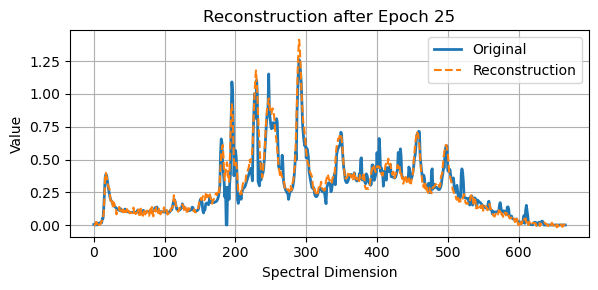

Epoch  26 | Train loss: 0.0084 | Val loss: 0.0083 | KL weight: 0.00


Epoch  27 | Train loss: 0.0084 | Val loss: 0.0083 | KL weight: 0.00


Epoch  28 | Train loss: 0.0084 | Val loss: 0.0084 | KL weight: 0.00


Epoch  29 | Train loss: 0.0085 | Val loss: 0.0085 | KL weight: 0.00


Epoch  30 | Train loss: 0.0085 | Val loss: 0.0087 | KL weight: 0.00


...

Epoch  46 | Train loss: 0.0089 | Val loss: 0.0088 | KL weight: 0.00


Epoch  47 | Train loss: 0.0089 | Val loss: 0.0088 | KL weight: 0.00


Epoch  48 | Train loss: 0.0089 | Val loss: 0.0088 | KL weight: 0.00


Epoch  49 | Train loss: 0.0089 | Val loss: 0.0089 | KL weight: 0.00


Epoch  50 | Train loss: 0.0090 | Val loss: 0.0089 | KL weight: 0.00


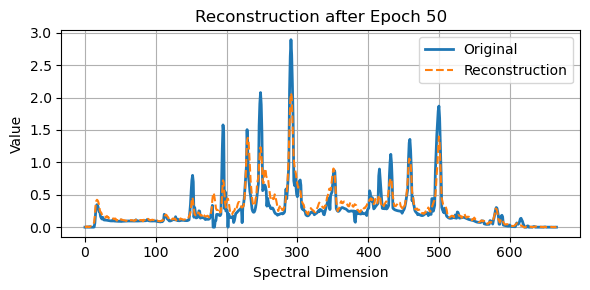

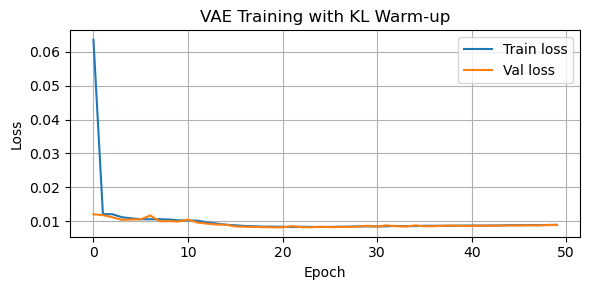

In [10]:
train_losses, val_losses, kl_weights = train_vae(modelPositional, train_loader, val_loader, num_epochs=50)

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

def visualize_latent_space(model, data_loader, device='cuda', method='pca', num_samples=1000):
    """
    Projects the latent space to 2D and plots it.
    
    Args:
        model: The VAE model
        data_loader: DataLoader (train or val)
        device: 'cuda' or 'cpu'
        method: 'pca' or 'umap'
        num_samples: Max number of samples to plot
    """
    model.eval()
    latents = []

    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            mu, _ = model.encode(batch)
            latents.append(mu.cpu().numpy())
            if len(latents) * batch.size(0) >= num_samples:
                break

    latents = np.vstack(latents)[:num_samples]  # Stack and clip to desired number

    # Dimensionality reduction
    if method.lower() == 'pca':
        reducer = PCA(n_components=2)
    elif method.lower() == 'umap':
        reducer = UMAP(n_components=2, random_state=42)
    else:
        raise ValueError(f"Unknown method '{method}', choose 'pca' or 'umap'.")

    latents_2d = reducer.fit_transform(latents)

    # Plot
    plt.figure(figsize=(6,4))
    plt.scatter(latents_2d[:,0], latents_2d[:,1], s=10, alpha=0.7)
    plt.title(f'Latent space visualization ({method.upper()})')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

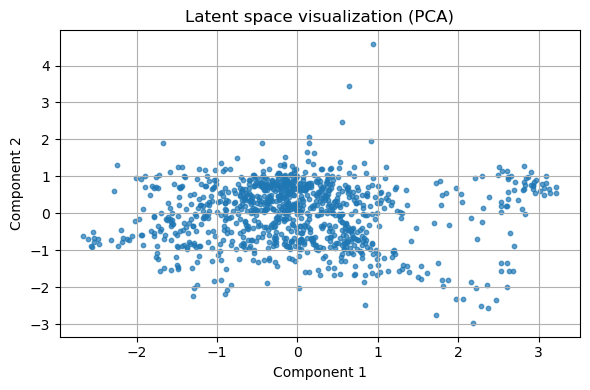

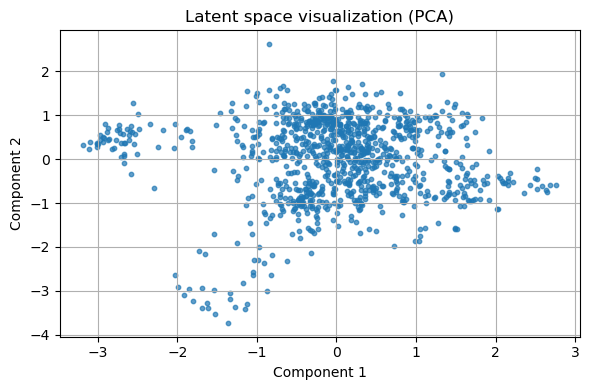

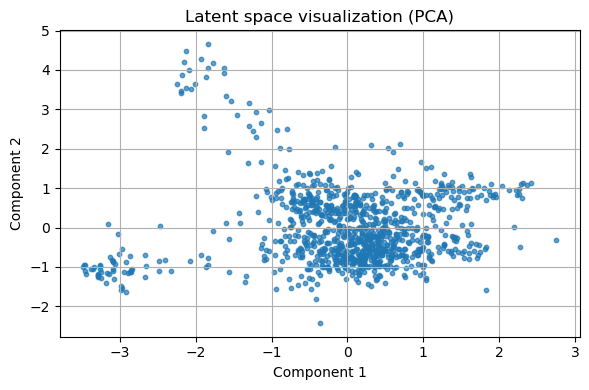

In [18]:
visualize_latent_space(modelCNN, val_loader, device='cuda', method='pca')
visualize_latent_space(modelHybrid, val_loader, device='cuda', method='pca')
visualize_latent_space(modelPositional, val_loader, device='cuda', method='pca')

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


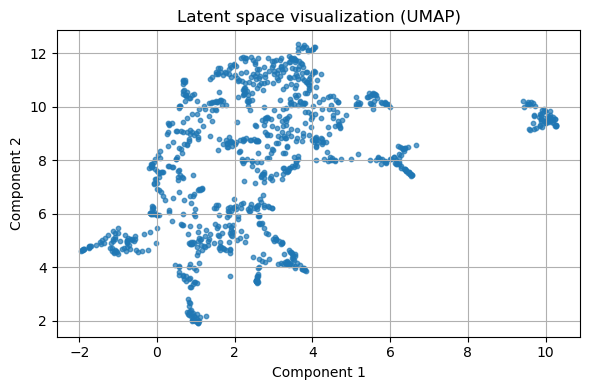

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


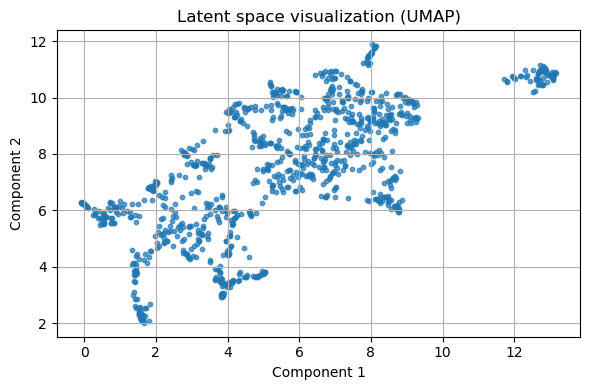

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


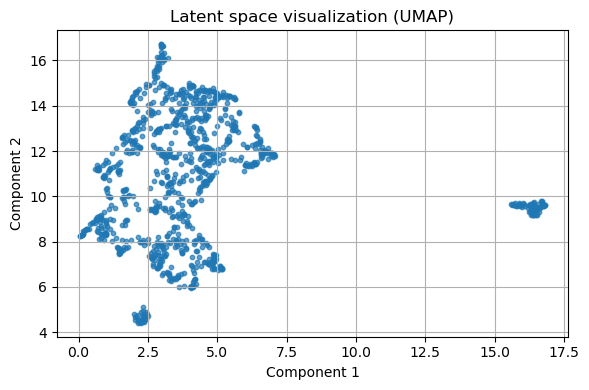

In [19]:
visualize_latent_space(modelCNN, val_loader, device='cuda', method='umap')
visualize_latent_space(modelHybrid, val_loader, device='cuda', method='umap')
visualize_latent_space(modelPositional, val_loader, device='cuda', method='umap')

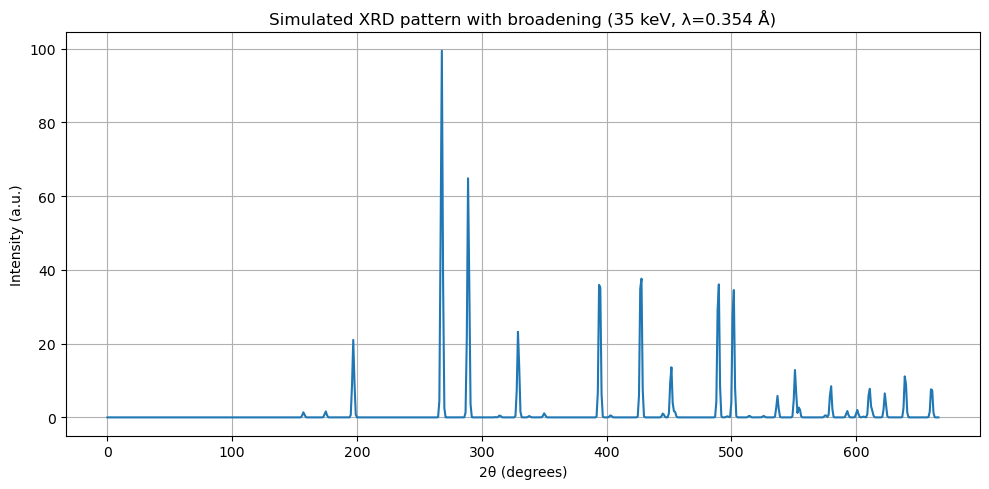

In [20]:
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# Load structure
structure = Structure.from_file("/dtu-compute/msaca/sliceA_diffraction/cif-files/1011033.cif")

# Set up XRD calculator
wavelength = 12.398 / 35  # 0.354 Å
xrd = XRDCalculator(wavelength=wavelength)

# Get pattern
pattern = xrd.get_pattern(structure)

# Set up fine 2theta grid
two_theta_grid = np.linspace(0, 18.408, 667)  # from 0 to 10 degrees, high resolution
intensity_grid = np.zeros_like(two_theta_grid)

# Simulate Gaussian broadening
peak_width = 0.05  # FWHM in degrees (adjust to match your instrument)

def gaussian(x, mu, fwhm):
    sigma = fwhm / (2*np.sqrt(2*np.log(2)))
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

for tth, intensity in zip(pattern.x, pattern.y):
    intensity_grid += intensity * gaussian(two_theta_grid, tth, peak_width)

# Plot
plt.figure(figsize=(10,5))
plt.plot(intensity_grid)
plt.xlabel("2θ (degrees)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Simulated XRD pattern with broadening (35 keV, λ={wavelength:.3f} Å)")
plt.grid(True)
plt.tight_layout()
plt.show()

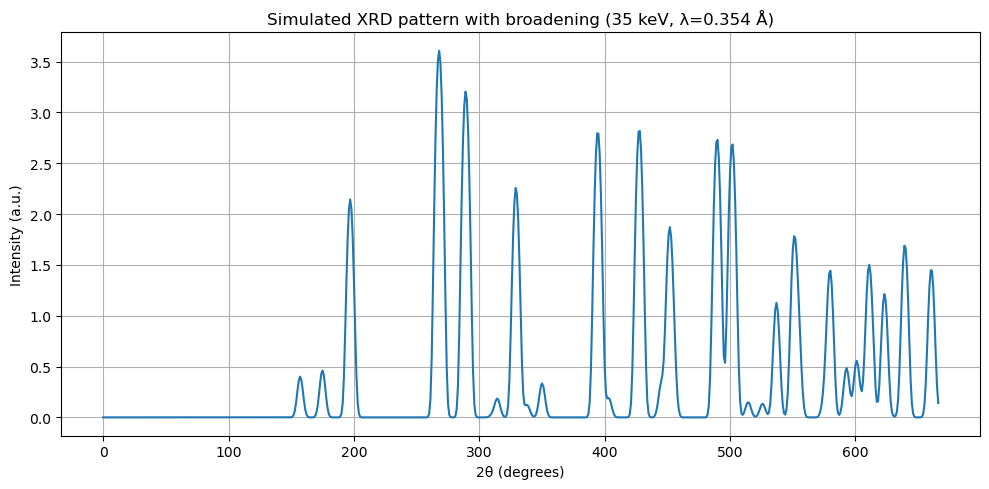

/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/zhome/71/c/146676/miniconda3/envs/cil5/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


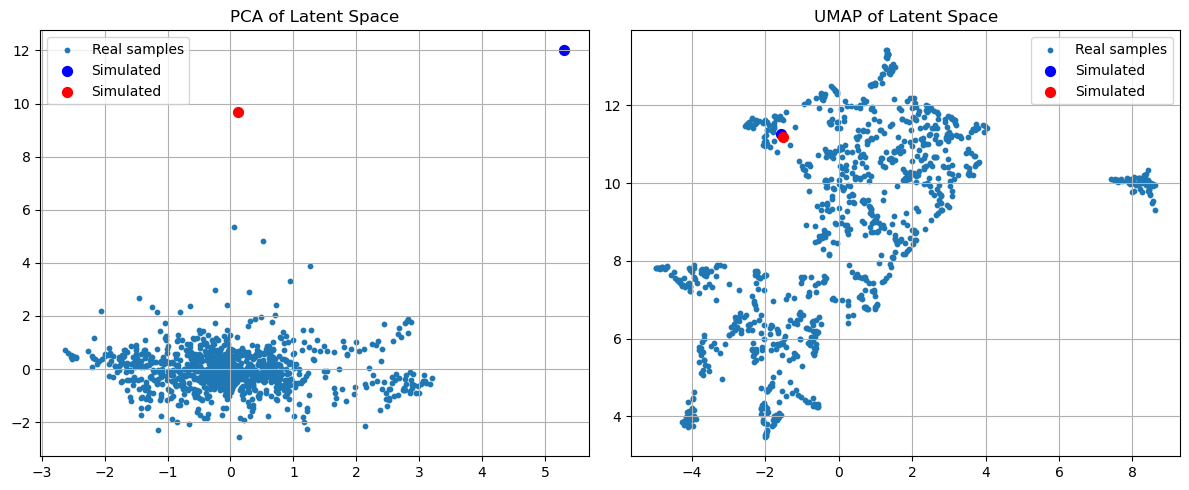

In [21]:
model = modelCNN
from scipy.ndimage import gaussian_filter1d
device='cuda'
# Convolve the intensity_grid
sigma = 2.0  # Choose sigma to match your instrumental broadening

def process(combined):
    #combined = combined / np.max(combined)     # Step 2: normalize max to 1
    combined = np.clip(combined, 0.001, None)  # Step 1: clip
    combined = np.log(combined+1)                # Step 3: log transform
    return combined

smoothed_intensity = process(gaussian_filter1d(intensity_grid, sigma=sigma))
smoothed_intensity2 = process(gaussian_filter1d(intensity_grid, sigma=sigma*3))

plt.figure(figsize=(10,5))
plt.plot(smoothed_intensity)
plt.xlabel("2θ (degrees)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Simulated XRD pattern with broadening (35 keV, λ={wavelength:.3f} Å)")
plt.grid(True)
plt.tight_layout()
plt.show()


simulated_input = torch.from_numpy(smoothed_intensity).float().unsqueeze(0).to(device)  # shape (1, 667)
simulated_input2 = torch.from_numpy(smoothed_intensity2).float().unsqueeze(0).to(device)  # shape (1, 667)
model.eval()
with torch.no_grad():
    mu, _ = model.encode(simulated_input)  # Get latent mean
    mu2, _ = model.encode(simulated_input2)  # Get latent mean
    simulated_latent = mu.cpu().numpy()  # shape (1, latent_dim)
    simulated_latent2 = mu2.cpu().numpy()  # shape (1, latent_dim)
real_latents = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        mu, _ = model.encode(batch)
        real_latents.append(mu.cpu().numpy())
        if len(real_latents) * batch.size(0) >= 1000:
            break

real_latents = np.vstack(real_latents)[:1000]  # shape (1000, latent_dim)
combined_latents = np.vstack([real_latents, simulated_latent,simulated_latent2])  # shape (1001, latent_dim)

# PCA
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(combined_latents)

# UMAP
umap = UMAP(n_components=2, random_state=42)
latent_umap = umap.fit_transform(combined_latents)

# Plot PCA
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(latent_pca[:-2,0], latent_pca[:-2,1], s=10, label='Real samples')
plt.scatter(latent_pca[-2,0], latent_pca[-2,1], color='blue', s=50, label='Simulated')
plt.scatter(latent_pca[-1,0], latent_pca[-1,1], color='red', s=50, label='Simulated')
plt.title('PCA of Latent Space')
plt.legend()
plt.grid(True)

# Plot UMAP
plt.subplot(1,2,2)
plt.scatter(latent_umap[:-2,0], latent_umap[:-2,1], s=10, label='Real samples')
plt.scatter(latent_umap[-2,0], latent_umap[-2,1], color='blue', s=50, label='Simulated')
plt.scatter(latent_umap[-1,0], latent_umap[-1,1], color='red', s=50, label='Simulated')
plt.title('UMAP of Latent Space')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

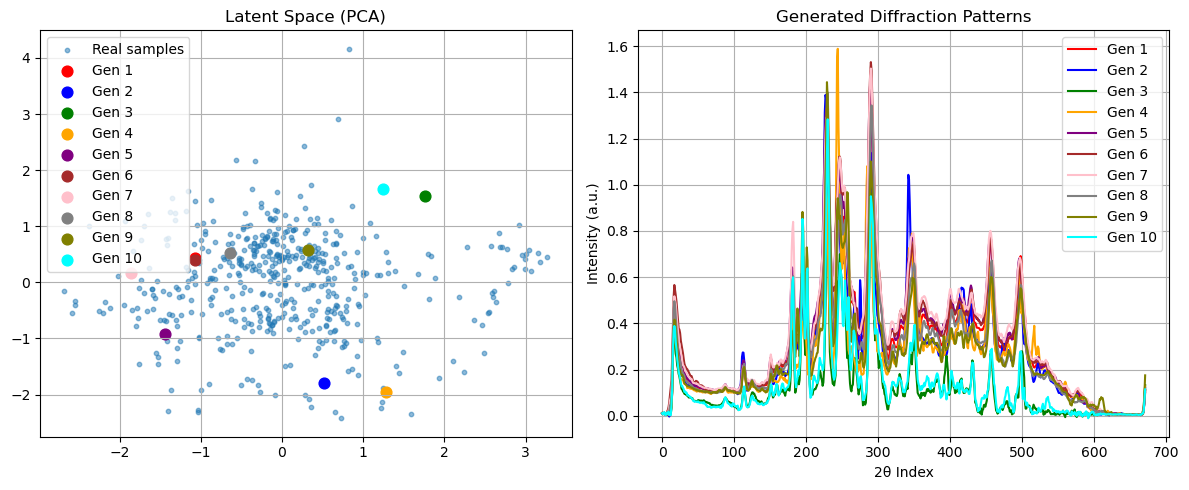

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
model = modelCNN

real_latents = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        mu, _ = model.encode(batch)
        real_latents.append(mu.cpu().numpy())
        if len(real_latents) * batch.size(0) >= 500:
            break

real_latents = np.vstack(real_latents)[:500]  # shape (1000, latent_dim)

latent_dim = model.latent_dim
num_samples = 10
scale = 1  # Optional scaling for tight sampling
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# 1. PCA projection of real samples
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(real_latents)  # shape (N_real, 2)

# 2. Sample random latent vectors
random_latents = scale * torch.randn(num_samples, latent_dim).to(device)

# 3. Decode them
model.eval()
with torch.no_grad():
    reconstructions = model.decode(random_latents).cpu().numpy()

# 4. PCA projection of random latent vectors
random_latents_np = random_latents.cpu().numpy()
random_latents_pca = pca.transform(random_latents_np)

# 5. Plot PCA with colored generated points
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(latent_pca[:, 0], latent_pca[:, 1], s=10, alpha=0.5, label='Real samples')
for i in range(num_samples):
    plt.scatter(random_latents_pca[i, 0], random_latents_pca[i, 1], 
                color=colors[i], label=f'Gen {i+1}', s=60)
plt.title('Latent Space (PCA)')
plt.legend()
plt.grid(True)

# 6. Plot reconstructed spectra with matching colors
plt.subplot(1, 2, 2)
for i in range(num_samples):
    plt.plot(reconstructions[i], color=colors[i], label=f'Gen {i+1}')
plt.title('Generated Diffraction Patterns')
plt.xlabel('2θ Index')
plt.ylabel('Intensity (a.u.)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()